In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from scipy.stats import entropy, skew

from skimage.color import rgb2gray, rgb2hsv
from skimage.transform import resize
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops, canny
from skimage.filters import laplace, sobel

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    balanced_accuracy_score, average_precision_score,
    precision_recall_curve
)
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

# =========================================================
# CONFIG
# =========================================================
DATA_DIR = Path("Fake Image Detection")
IMG_SIZE = (224, 224)
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

RUN_DIR = Path("run_stage1_production")
ARTIFACTS_DIR = RUN_DIR / "artifacts"
REPORTS_DIR = RUN_DIR / "reports"
for d in [RUN_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.20
CALIB_SIZE = 0.15          
N_SPLITS = 5

# Feature selection / projection
K_BEST_SVM = 4000
PCA_COMPONENTS_SVM = 800
K_BEST_XGB = 5000

# Ensemble
ENSEMBLE_W_XGB = 0.75
ENSEMBLE_W_SVM = 0.25

# Thresholds
TARGET_ACCEPT_PRECISION = 0.95
MIN_ACCEPT_RECALL = 0.35
REJECT_QUANTILE_NEG = 0.80

# HNM
USE_HNM = True
HNM_DUPLICATION = 2

# XGB config
XGB_PARAMS = dict(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.2,
    min_child_weight=3,
    reg_alpha=0.2,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# SVM config
SVM_PARAMS = dict(
    kernel="rbf",
    C=5,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)

# =========================================================
# DATA LOADING
# =========================================================
def collect_images(root: Path, label: int):
    paths, labels = [], []
    if not root.exists():
        return paths, labels

    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXTS:
            paths.append(str(p))
            labels.append(label)
    return paths, labels


irrelevant_paths, irrelevant_labels = collect_images(DATA_DIR / "irrelevant", 0)
relevant_paths, relevant_labels = collect_images(DATA_DIR / "relevant", 1)

paths = irrelevant_paths + relevant_paths
labels = irrelevant_labels + relevant_labels

df = pd.DataFrame({"path": paths, "label": labels})

print("Dataset size:", len(df))
print(df["label"].value_counts())

if len(df) < 100:
    raise ValueError("Dataset too small.")

# =========================================================
# FEATURE EXTRACTION
# =========================================================
def extract_features(path):
    img_pil = Image.open(path).convert("RGB")
    orig_w, orig_h = img_pil.size
    img = np.array(img_pil)

    img = resize(img, IMG_SIZE, anti_aliasing=True, preserve_range=True).astype(np.float32)
    if img.max() > 1.0:
        img /= 255.0

    gray = rgb2gray(img)
    hsv = rgb2hsv(img)

    # 1) HOG
    hog_feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    # 2) LBP
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)

    # 3) HSV histogram
    color_hist = []
    for ch in range(3):
        hist, _ = np.histogram(hsv[:, :, ch], bins=32, range=(0, 1), density=True)
        color_hist.extend(hist)

    # 4) Color moments
    color_moments = []
    for ch in range(3):
        vals = hsv[:, :, ch].ravel()
        color_moments.extend([
            np.mean(vals),
            np.std(vals),
            skew(vals)
        ])

    # 5) GLCM
    gray_u8 = (gray * 255).astype(np.uint8)
    glcm = graycomatrix(
        gray_u8,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2],
        levels=256,
        symmetric=True,
        normed=True
    )
    glcm_feat = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]:
        glcm_feat.extend(graycoprops(glcm, prop).ravel())

    # 6) Edge / sharpness
    edges = canny(gray)
    edge_density = edges.mean()

    sob = sobel(gray)
    sobel_hist, _ = np.histogram(sob.ravel(), bins=16, range=(0, 1), density=True)

    lap_var = laplace(gray).var()

    # 7) Global image stats
    gray_hist, _ = np.histogram(gray.ravel(), bins=64, range=(0, 1), density=True)
    ent = entropy(gray_hist + 1e-8)

    aspect_ratio = orig_w / (orig_h + 1e-8)
    brightness_mean = gray.mean()
    brightness_std = gray.std()

    global_feat = np.array([
        edge_density,
        lap_var,
        ent,
        aspect_ratio,
        brightness_mean,
        brightness_std,
        orig_w,
        orig_h
    ], dtype=np.float32)

    feat = np.concatenate([
        hog_feat.astype(np.float32),
        lbp_hist.astype(np.float32),
        np.array(color_hist, dtype=np.float32),
        np.array(color_moments, dtype=np.float32),
        np.array(glcm_feat, dtype=np.float32),
        sobel_hist.astype(np.float32),
        global_feat
    ]).astype(np.float32)

    return feat


print("\nExtracting features...")
X, y, kept_paths, failed = [], [], [], []

for path, label in tqdm(df[["path", "label"]].itertuples(index=False), total=len(df)):
    try:
        feat = extract_features(path)
        X.append(feat)
        y.append(label)
        kept_paths.append(path)
    except Exception as e:
        failed.append((path, str(e)))

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
paths_arr = np.array(kept_paths)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print("Feature matrix:", X.shape)
print("Failed images:", len(failed))

if len(X) == 0:
    raise ValueError("No features extracted.")

# =========================================================
# SPLITS
# =========================================================
X_train_full, X_test, y_train_full, y_test, paths_train_full, paths_test = train_test_split(
    X, y, paths_arr,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=42
)

print("\nHold-out split:")
print("Train Full:", X_train_full.shape, np.bincount(y_train_full))
print("Test      :", X_test.shape, np.bincount(y_test))

# =========================================================
# HELPERS
# =========================================================
def choose_accept_threshold(y_true, probs, target_precision=0.95, min_recall=0.35):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    precision = precision[:-1]
    recall = recall[:-1]

    candidates = []
    for p, r, t in zip(precision, recall, thresholds):
        if p >= target_precision and r >= min_recall:
            candidates.append((t, p, r))

    if len(candidates) > 0:
        best_t, best_p, best_r = sorted(candidates, key=lambda x: x[0])[0]
        return float(best_t), float(best_p), float(best_r), "target_precision"

    # fallback: best F1 threshold
    best_f1 = -1.0
    best_t = 0.5
    best_p = 0.0
    best_r = 0.0
    for p, r, t in zip(precision, recall, thresholds):
        denom = p + r
        f1 = 0.0 if denom == 0 else 2 * p * r / denom
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
            best_p = p
            best_r = r

    return float(best_t), float(best_p), float(best_r), "best_f1_fallback"


def choose_reject_threshold(y_true, probs, neg_quantile=0.80):
    neg_probs = probs[y_true == 0]
    if len(neg_probs) == 0:
        return 0.20
    return float(np.quantile(neg_probs, neg_quantile))


def compute_metrics(y_true, probs, accept_thr, reject_thr):
    pred_binary = (probs >= accept_thr).astype(int)

    decision = np.full(len(probs), "uncertain", dtype=object)
    decision[probs <= reject_thr] = "reject"
    decision[probs >= accept_thr] = "accept"

    n_accept = int(np.sum(decision == "accept"))
    n_reject = int(np.sum(decision == "reject"))
    n_uncertain = int(np.sum(decision == "uncertain"))

    accept_correct = int(np.sum((decision == "accept") & (y_true == 1)))
    reject_correct = int(np.sum((decision == "reject") & (y_true == 0)))

    out = {
        "accuracy": accuracy_score(y_true, pred_binary),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred_binary),
        "precision": precision_score(y_true, pred_binary, zero_division=0),
        "recall": recall_score(y_true, pred_binary, zero_division=0),
        "f1": f1_score(y_true, pred_binary, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs),
        "confusion_matrix": confusion_matrix(y_true, pred_binary),
        "classification_report": classification_report(y_true, pred_binary, digits=4, zero_division=0),
        "n_accept": n_accept,
        "n_reject": n_reject,
        "n_uncertain": n_uncertain,
        "accept_precision_tri": accept_correct / max(n_accept, 1),
        "reject_precision_tri": reject_correct / max(n_reject, 1),
        "coverage": (n_accept + n_reject) / len(y_true)
    }
    return out, pred_binary, decision


# =========================================================
# PREPROCESSING CLASSES
# =========================================================
class SVMPreprocessor:
    def __init__(self, k_best=4000, pca_components=800):
        self.k_best = k_best
        self.pca_components = pca_components
        self.selector = None
        self.pca = None
        self.scaler = None

    def fit(self, X, y):
        self.selector = SelectKBest(score_func=f_classif, k=min(self.k_best, X.shape[1]))
        X_sel = self.selector.fit_transform(X, y)

        n_comp = min(self.pca_components, X_sel.shape[1], X_sel.shape[0] - 1)
        self.pca = PCA(n_components=n_comp, random_state=42)
        X_pca = self.pca.fit_transform(X_sel)

        self.scaler = StandardScaler()
        self.scaler.fit(X_pca)
        return self

    def transform(self, X):
        X_sel = self.selector.transform(X)
        X_pca = self.pca.transform(X_sel)
        X_sc = self.scaler.transform(X_pca)
        return X_sc


class XGBPreprocessor:
    def __init__(self, k_best=5000):
        self.k_best = k_best
        self.selector = None

    def fit(self, X, y):
        self.selector = SelectKBest(score_func=f_classif, k=min(self.k_best, X.shape[1]))
        self.selector.fit(X, y)
        return self

    def transform(self, X):
        return self.selector.transform(X)


def build_models(y_train):
    neg = int((y_train == 0).sum())
    pos = int((y_train == 1).sum())
    scale_pos_weight = neg / max(pos, 1)

    xgb_params = XGB_PARAMS.copy()
    xgb_params["scale_pos_weight"] = scale_pos_weight

    xgb = XGBClassifier(**xgb_params)
    svm = SVC(**SVM_PARAMS)
    return xgb, svm


def train_dual_models(X_train, y_train):
    svm_prep = SVMPreprocessor(k_best=K_BEST_SVM, pca_components=PCA_COMPONENTS_SVM).fit(X_train, y_train)
    xgb_prep = XGBPreprocessor(k_best=K_BEST_XGB).fit(X_train, y_train)

    X_train_svm = svm_prep.transform(X_train)
    X_train_xgb = xgb_prep.transform(X_train)

    xgb_model, svm_model = build_models(y_train)
    xgb_model.fit(X_train_xgb, y_train)
    svm_model.fit(X_train_svm, y_train)

    return svm_prep, xgb_prep, svm_model, xgb_model


def ensemble_probs(xgb_model, svm_model, xgb_prep, svm_prep, X):
    X_xgb = xgb_prep.transform(X)
    X_svm = svm_prep.transform(X)

    p_xgb = xgb_model.predict_proba(X_xgb)[:, 1]
    p_svm = svm_model.predict_proba(X_svm)[:, 1]
    p_ens = ENSEMBLE_W_XGB * p_xgb + ENSEMBLE_W_SVM * p_svm
    return p_xgb, p_svm, p_ens


# =========================================================
# K-FOLD CV ON TRAIN ONLY
# =========================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_rows = []

print("\n==============================")
print("K-FOLD CROSS VALIDATION START")
print("==============================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), start=1):
    print(f"\n===== FOLD {fold}/{N_SPLITS} =====")

    X_tr = X_train_full[train_idx]
    y_tr = y_train_full[train_idx]
    paths_tr = paths_train_full[train_idx]

    X_va = X_train_full[val_idx]
    y_va = y_train_full[val_idx]
    paths_va = paths_train_full[val_idx]

    # Initial fit
    svm_prep, xgb_prep, svm_model, xgb_model = train_dual_models(X_tr, y_tr)
    _, _, va_probs_before_hnm = ensemble_probs(xgb_model, svm_model, xgb_prep, svm_prep, X_va)

    # Hard negative mining
    if USE_HNM:
        tmp_accept_thr, _, _, _ = choose_accept_threshold(
            y_va, va_probs_before_hnm,
            target_precision=TARGET_ACCEPT_PRECISION,
            min_recall=MIN_ACCEPT_RECALL
        )
        tmp_pred = (va_probs_before_hnm >= tmp_accept_thr).astype(int)
        fp_mask = (y_va == 0) & (tmp_pred == 1)

        hard_neg_X = X_va[fp_mask]
        hard_neg_y = y_va[fp_mask]
        hard_neg_paths = paths_va[fp_mask]

        print("Hard negatives found:", len(hard_neg_X))

        if len(hard_neg_X) > 0:
            X_tr_hnm = np.vstack([X_tr] + [hard_neg_X] * HNM_DUPLICATION)
            y_tr_hnm = np.concatenate([y_tr] + [hard_neg_y] * HNM_DUPLICATION)
            paths_tr_hnm = np.concatenate([paths_tr] + [hard_neg_paths] * HNM_DUPLICATION)
        else:
            X_tr_hnm = X_tr.copy()
            y_tr_hnm = y_tr.copy()
            paths_tr_hnm = paths_tr.copy()

        svm_prep, xgb_prep, svm_model, xgb_model = train_dual_models(X_tr_hnm, y_tr_hnm)
    else:
        X_tr_hnm = X_tr.copy()
        y_tr_hnm = y_tr.copy()
        paths_tr_hnm = paths_tr.copy()

    _, _, va_probs = ensemble_probs(xgb_model, svm_model, xgb_prep, svm_prep, X_va)

    accept_thr, accept_p, accept_r, accept_mode = choose_accept_threshold(
        y_va, va_probs,
        target_precision=TARGET_ACCEPT_PRECISION,
        min_recall=MIN_ACCEPT_RECALL
    )
    reject_thr = choose_reject_threshold(
        y_va, va_probs,
        neg_quantile=REJECT_QUANTILE_NEG
    )

    if reject_thr >= accept_thr:
        reject_thr = max(0.0, accept_thr - 0.10)

    metrics, pred_binary, decision = compute_metrics(y_va, va_probs, accept_thr, reject_thr)

    print(f"Accept threshold: {accept_thr:.4f}")
    print(f"Reject threshold: {reject_thr:.4f}")
    print(f"Accuracy        : {metrics['accuracy']:.4f}")
    print(f"Precision       : {metrics['precision']:.4f}")
    print(f"Recall          : {metrics['recall']:.4f}")
    print(f"F1              : {metrics['f1']:.4f}")
    print(f"ROC AUC         : {metrics['roc_auc']:.4f}")
    print(f"PR AUC          : {metrics['pr_auc']:.4f}")
    print(f"Coverage        : {metrics['coverage']:.4f}")

    fold_rows.append({
        "fold": fold,
        "train_size": len(X_tr),
        "val_size": len(X_va),
        "train_size_after_hnm": len(paths_tr_hnm),
        "accept_threshold": accept_thr,
        "reject_threshold": reject_thr,
        "accept_mode": accept_mode,
        "accept_threshold_precision": accept_p,
        "accept_threshold_recall": accept_r,
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
        "tri_accept_precision": metrics["accept_precision_tri"],
        "tri_reject_precision": metrics["reject_precision_tri"],
        "coverage": metrics["coverage"],
        "hard_negatives_found": int(np.sum((y_va == 0) & (pred_binary == 1)))
    })

cv_df = pd.DataFrame(fold_rows)
cv_df.to_csv(REPORTS_DIR / "cv_results.csv", index=False)

print("\n===== CROSS-VALIDATION SUMMARY =====")
print(cv_df[[
    "accuracy", "balanced_accuracy", "precision", "recall",
    "f1", "roc_auc", "pr_auc", "coverage"
]].mean())

# =========================================================
# FINAL TRAINING + CALIBRATION
# =========================================================
print("\n==============================")
print("FINAL TRAINING + CALIBRATION")
print("==============================")

X_train, X_calib, y_train, y_calib, paths_train, paths_calib = train_test_split(
    X_train_full, y_train_full, paths_train_full,
    test_size=CALIB_SIZE,
    stratify=y_train_full,
    random_state=42
)

# Initial final train
svm_prep_final, xgb_prep_final, svm_model_final, xgb_model_final = train_dual_models(X_train, y_train)
_, _, calib_probs_before_hnm = ensemble_probs(
    xgb_model_final, svm_model_final, xgb_prep_final, svm_prep_final, X_calib
)

# HNM on final-train using calibration false positives
if USE_HNM:
    tmp_accept_thr, _, _, _ = choose_accept_threshold(
        y_calib, calib_probs_before_hnm,
        target_precision=TARGET_ACCEPT_PRECISION,
        min_recall=MIN_ACCEPT_RECALL
    )
    tmp_pred = (calib_probs_before_hnm >= tmp_accept_thr).astype(int)
    fp_mask = (y_calib == 0) & (tmp_pred == 1)

    hard_neg_X = X_calib[fp_mask]
    hard_neg_y = y_calib[fp_mask]

    print("Final HNM hard negatives found:", len(hard_neg_X))

    if len(hard_neg_X) > 0:
        X_train_hnm = np.vstack([X_train] + [hard_neg_X] * HNM_DUPLICATION)
        y_train_hnm = np.concatenate([y_train] + [hard_neg_y] * HNM_DUPLICATION)
    else:
        X_train_hnm = X_train.copy()
        y_train_hnm = y_train.copy()

    svm_prep_final, xgb_prep_final, svm_model_final, xgb_model_final = train_dual_models(X_train_hnm, y_train_hnm)

# Calibration thresholds from calibration set only
_, _, calib_probs = ensemble_probs(
    xgb_model_final, svm_model_final, xgb_prep_final, svm_prep_final, X_calib
)

final_accept_thr, calib_p, calib_r, calib_mode = choose_accept_threshold(
    y_calib, calib_probs,
    target_precision=TARGET_ACCEPT_PRECISION,
    min_recall=MIN_ACCEPT_RECALL
)
final_reject_thr = choose_reject_threshold(y_calib, calib_probs, neg_quantile=REJECT_QUANTILE_NEG)

if final_reject_thr >= final_accept_thr:
    final_reject_thr = max(0.0, final_accept_thr - 0.10)

print(f"Final accept threshold: {final_accept_thr:.4f}")
print(f"Final reject threshold: {final_reject_thr:.4f}")

# =========================================================
# TEST EVALUATION
# =========================================================
xgb_test_prob, svm_test_prob, ens_test_prob = ensemble_probs(
    xgb_model_final, svm_model_final, xgb_prep_final, svm_prep_final, X_test
)

test_metrics, test_pred_binary, test_decision = compute_metrics(
    y_test, ens_test_prob, final_accept_thr, final_reject_thr
)

print("\n===== FINAL TEST RESULTS =====")
print("Accuracy:", round(test_metrics["accuracy"], 4))
print("Balanced Accuracy:", round(test_metrics["balanced_accuracy"], 4))
print("Precision:", round(test_metrics["precision"], 4))
print("Recall:", round(test_metrics["recall"], 4))
print("F1:", round(test_metrics["f1"], 4))
print("ROC AUC:", round(test_metrics["roc_auc"], 4))
print("PR AUC:", round(test_metrics["pr_auc"], 4))
print("\nConfusion Matrix:\n", test_metrics["confusion_matrix"])
print("\nClassification Report:\n", test_metrics["classification_report"])

print("\n===== FINAL TEST TRI-STATE =====")
print("Accepted samples  :", test_metrics["n_accept"])
print("Rejected samples  :", test_metrics["n_reject"])
print("Uncertain samples :", test_metrics["n_uncertain"])
print("Accept precision  :", round(test_metrics["accept_precision_tri"], 4))
print("Reject precision  :", round(test_metrics["reject_precision_tri"], 4))
print("Coverage          :", round(test_metrics["coverage"], 4))

# =========================================================
# ERROR ANALYSIS
# =========================================================
test_fp_mask = (y_test == 0) & (test_pred_binary == 1)
test_fn_mask = (y_test == 1) & (test_pred_binary == 0)

pd.DataFrame({
    "path": paths_test[test_fp_mask],
    "true_label": y_test[test_fp_mask],
    "score": ens_test_prob[test_fp_mask]
}).to_csv(REPORTS_DIR / "test_false_positives.csv", index=False)

pd.DataFrame({
    "path": paths_test[test_fn_mask],
    "true_label": y_test[test_fn_mask],
    "score": ens_test_prob[test_fn_mask]
}).to_csv(REPORTS_DIR / "test_false_negatives.csv", index=False)

pd.DataFrame({
    "path": paths_test,
    "true_label": y_test,
    "xgb_score": xgb_test_prob,
    "svm_score": svm_test_prob,
    "ensemble_score": ens_test_prob,
    "binary_pred": test_pred_binary,
    "tri_decision": test_decision
}).to_csv(REPORTS_DIR / "test_predictions_full.csv", index=False)

# =========================================================
# SAVE ARTIFACTS
# =========================================================
artifact_bundle = {
    "svm_preprocessor": svm_prep_final,
    "xgb_preprocessor": xgb_prep_final,
    "svm_model": svm_model_final,
    "xgb_model": xgb_model_final,
    "ensemble_w_xgb": ENSEMBLE_W_XGB,
    "ensemble_w_svm": ENSEMBLE_W_SVM,
    "accept_threshold": final_accept_thr,
    "reject_threshold": final_reject_thr,
    "img_size": IMG_SIZE,
    "class_mapping": {"irrelevant": 0, "relevant": 1}
}

joblib.dump(artifact_bundle, ARTIFACTS_DIR / "stage1_bundle.joblib")

config = {
    "data_dir": str(DATA_DIR),
    "img_size": IMG_SIZE,
    "test_size": TEST_SIZE,
    "calib_size": CALIB_SIZE,
    "n_splits": N_SPLITS,
    "k_best_svm": K_BEST_SVM,
    "pca_components_svm": PCA_COMPONENTS_SVM,
    "k_best_xgb": K_BEST_XGB,
    "ensemble_w_xgb": ENSEMBLE_W_XGB,
    "ensemble_w_svm": ENSEMBLE_W_SVM,
    "accept_threshold": float(final_accept_thr),
    "reject_threshold": float(final_reject_thr),
    "target_accept_precision": TARGET_ACCEPT_PRECISION,
    "min_accept_recall": MIN_ACCEPT_RECALL,
    "reject_quantile_neg": REJECT_QUANTILE_NEG,
    "use_hnm": USE_HNM,
    "hnm_duplication": HNM_DUPLICATION,
    "threshold_mode": calib_mode,
    "calibration_precision": float(calib_p),
    "calibration_recall": float(calib_r),
    "cv_mean_metrics": {
        "accuracy": float(cv_df["accuracy"].mean()),
        "balanced_accuracy": float(cv_df["balanced_accuracy"].mean()),
        "precision": float(cv_df["precision"].mean()),
        "recall": float(cv_df["recall"].mean()),
        "f1": float(cv_df["f1"].mean()),
        "roc_auc": float(cv_df["roc_auc"].mean()),
        "pr_auc": float(cv_df["pr_auc"].mean()),
        "coverage": float(cv_df["coverage"].mean())
    },
    "final_test_metrics": {
        "accuracy": float(test_metrics["accuracy"]),
        "balanced_accuracy": float(test_metrics["balanced_accuracy"]),
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "f1": float(test_metrics["f1"]),
        "roc_auc": float(test_metrics["roc_auc"]),
        "pr_auc": float(test_metrics["pr_auc"]),
        "coverage": float(test_metrics["coverage"]),
        "accept_precision_tri": float(test_metrics["accept_precision_tri"]),
        "reject_precision_tri": float(test_metrics["reject_precision_tri"])
    }
}

with open(ARTIFACTS_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# =========================================================
# SINGLE IMAGE INFERENCE
# =========================================================
def predict_single_image(image_path, bundle_path=ARTIFACTS_DIR / "stage1_bundle.joblib"):
    bundle = joblib.load(bundle_path)

    svm_prep = bundle["svm_preprocessor"]
    xgb_prep = bundle["xgb_preprocessor"]
    svm_model = bundle["svm_model"]
    xgb_model = bundle["xgb_model"]

    w_xgb = bundle["ensemble_w_xgb"]
    w_svm = bundle["ensemble_w_svm"]
    accept_thr = bundle["accept_threshold"]
    reject_thr = bundle["reject_threshold"]

    feat = extract_features(image_path).reshape(1, -1)
    feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)

    feat_xgb = xgb_prep.transform(feat)
    feat_svm = svm_prep.transform(feat)

    p_xgb = xgb_model.predict_proba(feat_xgb)[:, 1][0]
    p_svm = svm_model.predict_proba(feat_svm)[:, 1][0]
    p = w_xgb * p_xgb + w_svm * p_svm

    if p >= accept_thr:
        decision = "accept"
        pred_label = 1
        pred_class = "relevant"
    elif p <= reject_thr:
        decision = "reject"
        pred_label = 0
        pred_class = "irrelevant"
    else:
        decision = "uncertain"
        pred_label = -1
        pred_class = "uncertain"

    return {
        "path": image_path,
        "decision": decision,
        "pred_label": pred_label,
        "pred_class": pred_class,
        "score": float(p),
        "accept_threshold": float(accept_thr),
        "reject_threshold": float(reject_thr),
        "xgb_score": float(p_xgb),
        "svm_score": float(p_svm)
    }


print("\nSaved reports in:", REPORTS_DIR)
print("Saved artifacts in:", ARTIFACTS_DIR)
print("\nStage 1 pipeline finished successfully.")

Dataset size: 5026
label
0    3021
1    2005
Name: count, dtype: int64

Extracting features...


100%|██████████| 5026/5026 [35:14<00:00,  2.38it/s]  


Feature matrix: (5026, 26419)
Failed images: 0

Hold-out split:
Train Full: (4020, 26419) [2416 1604]
Test      : (1006, 26419) [605 401]

K-FOLD CROSS VALIDATION START

===== FOLD 1/5 =====
Hard negatives found: 14
Accept threshold: 0.3051
Reject threshold: 0.0774
Accuracy        : 0.9552
Precision       : 0.9524
Recall          : 0.9346
F1              : 0.9434
ROC AUC         : 0.9903
PR AUC          : 0.9878
Coverage        : 0.8781

===== FOLD 2/5 =====
Hard negatives found: 15
Accept threshold: 0.2440
Reject threshold: 0.0722
Accuracy        : 0.9602
Precision       : 0.9502
Recall          : 0.9502
F1              : 0.9502
ROC AUC         : 0.9834
PR AUC          : 0.9847
Coverage        : 0.8918

===== FOLD 3/5 =====
Hard negatives found: 14
Accept threshold: 0.3481
Reject threshold: 0.0726
Accuracy        : 0.9502
Precision       : 0.9518
Recall          : 0.9221
F1              : 0.9367
ROC AUC         : 0.9861
PR AUC          : 0.9856
Coverage        : 0.8756

===== FOLD 4/5

In [5]:
import pandas as pd

df = pd.read_csv("run_stage1_production/reports/cv_results.csv")

print("Average Accuracy:", df["accuracy"].mean())

Average Accuracy: 0.9547263681592039


In [6]:
print("\n===== AVERAGE METRICS =====")

metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "coverage"
]

for m in metrics:
    print(f"{m}: {df[m].mean():.4f}")


===== AVERAGE METRICS =====
accuracy: 0.9547
balanced_accuracy: 0.9512
precision: 0.9517
recall: 0.9339
f1: 0.9427
roc_auc: 0.9881
pr_auc: 0.9867
coverage: 0.8789


In [7]:

fold_table = df[["fold"] + metrics]

print("===== K-FOLD RESULTS =====")
display(fold_table)

avg_results = df[metrics].mean().to_frame(name="Average")

print("\n===== AVERAGE METRICS =====")
display(avg_results)

===== K-FOLD RESULTS =====


,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,coverage
0,1,0.955224,0.951762,0.952381,0.934579,0.943396,0.990299,0.987793,0.878109
1,2,0.960199,0.958515,0.950156,0.950156,0.950156,0.983424,0.984720,0.891791
2,3,0.950249,0.945531,0.951768,0.922118,0.936709,0.986114,0.985565,0.875622
3,4,0.957711,0.954877,0.952681,0.940810,0.946708,0.991177,0.988970,0.879353
4,5,0.950249,0.945442,0.951613,0.921875,0.936508,0.989437,0.986513,0.869403



===== AVERAGE METRICS =====


,Average
accuracy,0.954726
balanced_accuracy,0.951225
precision,0.951720
recall,0.933908
f1,0.942695
roc_auc,0.988090
pr_auc,0.986712
coverage,0.878856


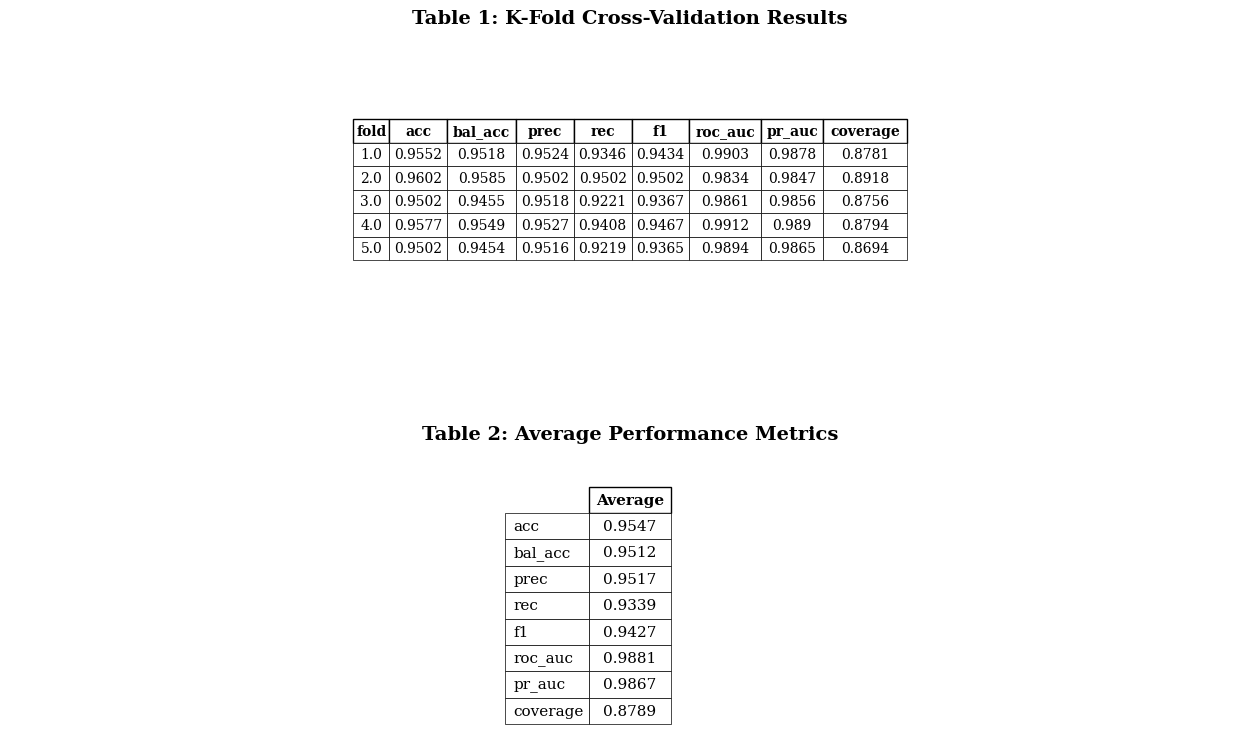

In [14]:
import matplotlib.pyplot as plt


fold_table = df[["fold"] + metrics].copy()
fold_table["fold"] = fold_table["fold"].astype(int)
fold_table = fold_table.round(4)


fold_table = fold_table.rename(columns={
    "balanced_accuracy": "bal_acc",
    "precision": "prec",
    "recall": "rec",
    "accuracy": "acc"
})

avg_table = df[metrics].mean().to_frame(name="Average").round(4)
avg_table = avg_table.rename(index={
    "balanced_accuracy": "bal_acc",
    "precision": "prec",
    "recall": "rec",
    "accuracy": "acc"
})


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.patch.set_facecolor("white")


axes[0].axis("off")

axes[0].text(
    0.5, 1.1,
    "Table 1: K-Fold Cross-Validation Results",
    fontsize=14,
    fontweight="bold",
    ha="center",
    transform=axes[0].transAxes
)

table1 = axes[0].table(
    cellText=fold_table.values,
    colLabels=fold_table.columns,
    cellLoc="center",
    loc="center"
)

table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1.2, 1.6)
table1.auto_set_column_width(col=list(range(len(fold_table.columns))))

for (row, col), cell in table1.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)


    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_linewidth(1.0)


axes[1].axis("off")

axes[1].text(
    0.5, 1.1,
    "Table 2: Average Performance Metrics",
    fontsize=14,
    fontweight="bold",
    ha="center",
    transform=axes[1].transAxes
)

table2 = axes[1].table(
    cellText=avg_table.values,
    rowLabels=avg_table.index,
    colLabels=avg_table.columns,
    cellLoc="center",
    loc="center"
)

table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1.2, 1.8)
table2.auto_set_column_width(col=[0, 1])

for (row, col), cell in table2.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)

    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_linewidth(1.0)


plt.subplots_adjust(hspace=0.5)

plt.savefig(
    "IEEE_style_results.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

In [10]:
import joblib

joblib.dump(svm_prep_final, "run_stage1_production/svm_preprocessor.pkl")
joblib.dump(xgb_prep_final, "run_stage1_production/xgb_preprocessor.pkl")
joblib.dump(svm_model_final, "run_stage1_production/svm_model.pkl")
joblib.dump(xgb_model_final, "run_stage1_production/xgb_model.pkl")

['run_stage1_production/xgb_model.pkl']

In [1]:
import joblib
from pathlib import Path

# ابحثي عن الملفات
artifacts_path = Path("run_stage1_production/artifacts")
print("الملفات الموجودة:")
for p in artifacts_path.glob("*.pkl"):
    print(p)

الملفات الموجودة:
